In [32]:
import cv2
import numpy as np
from ultralytics import YOLO
from collections import deque
import pandas as pd
from scipy.signal import savgol_filter

# ==============================================================
# 1. Configuration
# ==============================================================

MODEL_PATH = r"C:\Users\lynch\runs\pose\train6\weights\best.pt"

VIDEOS = [
    {"input": r"C:\Users\lynch\OneDrive\Syracuse\Computer Vision\Women's Lacrosse\YOLO Model\IMG_4572.MOV", 
     "output_video": "2026_05_13_Example_output.avi", 
     "output_csv": "2026_05_13_example.csv"}
]

print("="*60)
print("INITIALIZING - MAXIMUM ACCURACY MODE")
print("="*60)
print(f"Loading YOLO model from: {MODEL_PATH}")
model = YOLO(MODEL_PATH)
print("✓ Model loaded successfully")

DEVICE = "cpu"
print(f"✓ Device set to: {DEVICE}")

# ==============================================================
# 2. Pose Structure
# ==============================================================
NUM_JOINTS = 20
JOINT_NAMES = [
    'right_toe', 'right_heel', 'right_ankle',
    'left_toe', 'left_heel', 'left_ankle',
    'right_knee', 'left_knee',
    'right_hip', 'left_hip', 'pelvis',
    'right_shoulder', 'right_elbow', 'right_wrist', 'right_hand',
    'left_shoulder', 'left_elbow', 'left_wrist', 'left_hand',
    'head'
]

SKELETON_EDGES = [
    (10, 8), (10, 9),
    (8, 6), (9, 7),
    (6, 2), (7, 5),
    (2, 1), (5, 4),
    (1, 0), (4, 3),
    (10, 11), (11, 12), (12, 13), (13, 14),
    (10, 15), (15, 16), (16, 17), (17, 18),
    (10, 19)
]

FOOT_JOINTS = {0, 1, 2, 3, 4, 5}
LEG_JOINTS = {0, 1, 2, 3, 4, 5, 6, 7, 8, 9}
CORE_JOINTS = {10}
UPPER_BODY = {10, 11, 12, 13, 14, 15, 16, 17, 18, 19}

# ==============================================================
# 3. Leg Tracker
# ==============================================================
class SmartLegTracker:
    def __init__(self):
        self.prev_keypoints = None
        
    def correct_and_track(self, keypoints, confs):
        if self.prev_keypoints is None:
            self.prev_keypoints = keypoints.copy()
        else:
            self.prev_keypoints = keypoints.copy()
        return keypoints

# ==============================================================
# 4. Foot Strike Detection
# ==============================================================
class FootStrikeDetector:
    def __init__(self):
        self.history_len = 8
        self.right_heel_y = deque(maxlen=self.history_len)
        self.left_heel_y = deque(maxlen=self.history_len)
    
    def update(self, keypoints):
        self.right_heel_y.append(keypoints[1][1])
        self.left_heel_y.append(keypoints[4][1])
    
    def get_foot_state(self):
        if len(self.right_heel_y) < 4:
            return 'unknown', 'unknown'
        
        right_recent = list(self.right_heel_y)[-4:]
        left_recent = list(self.left_heel_y)[-4:]
        
        right_stable = np.std(right_recent) < 4
        left_stable = np.std(left_recent) < 4
        
        return ('contact' if right_stable else 'swing',
                'contact' if left_stable else 'swing')

# ==============================================================
# 5. Raw Data Collector
# ==============================================================
class RawDataCollector:
    def __init__(self):
        self.frames = []
        self.keypoints_raw = []
        self.confidences_raw = []
        self.foot_states = []
        
    def add_frame(self, frame_num, keypoints, confidences, foot_states):
        self.frames.append(frame_num)
        self.keypoints_raw.append(keypoints.copy())
        self.confidences_raw.append(confidences.copy())
        self.foot_states.append(foot_states)
    
    def get_arrays(self):
        return {
            'frames': np.array(self.frames),
            'keypoints': np.array(self.keypoints_raw),
            'confidences': np.array(self.confidences_raw),
            'foot_states': self.foot_states
        }

# ==============================================================
# 6. Savitzky-Golay Filter
# ==============================================================
def apply_savgol_filter(data, fps, window_frames=7):
    filtered_data = np.zeros_like(data)
    n_frames, n_joints, n_coords = data.shape
    
    if window_frames % 2 == 0:
        window_frames += 1
    
    polyorder = 2
    
    for joint in range(n_joints):
        for coord in range(n_coords):
            signal = data[:, joint, coord]
            
            if len(signal) > window_frames:
                filtered_data[:, joint, coord] = savgol_filter(signal, window_frames, polyorder, mode='nearest')
            else:
                filtered_data[:, joint, coord] = signal
    
    return filtered_data

# ==============================================================
# 7. Gap Filling
# ==============================================================
def fill_gaps_confidence_weighted(keypoints, confidences, threshold=0.15):
    filled_keypoints = keypoints.copy()
    n_frames, n_joints, _ = keypoints.shape
    
    for joint in range(n_joints):
        for coord in range(2):
            signal = keypoints[:, joint, coord]
            conf = confidences[:, joint]
            
            valid_mask = conf > threshold
            valid_indices = np.where(valid_mask)[0]
            
            if len(valid_indices) < 2:
                continue
            
            for i in range(len(valid_indices) - 1):
                start_idx = valid_indices[i]
                end_idx = valid_indices[i + 1]
                gap_size = end_idx - start_idx
                
                if gap_size <= 3 and conf[start_idx] > 0.5 and conf[end_idx] > 0.5:
                    gap_frames = np.arange(start_idx + 1, end_idx)
                    filled_keypoints[gap_frames, joint, coord] = np.interp(
                        gap_frames,
                        [start_idx, end_idx],
                        [signal[start_idx], signal[end_idx]]
                    )
    
    return filled_keypoints

# ==============================================================
# 8. Data Exporter
# ==============================================================
class DataExporter:
    def __init__(self, init_frames=30):
        self.init_frames = init_frames
        self.ground_y = None
        self.pelvis_x_median = None
        
    def initialize_references(self, keypoints, confidences):
        n_frames = min(self.init_frames, len(keypoints))
        
        pelvis_x_values = []
        for i in range(n_frames):
            if confidences[i, 10] > 0.5:
                pelvis_x_values.append(keypoints[i, 10, 0])
        
        self.pelvis_x_median = np.median(pelvis_x_values) if pelvis_x_values else keypoints[0, 10, 0]
        
        heel_y_values = []
        for i in range(n_frames):
            for heel_joint in [1, 4]:
                if confidences[i, heel_joint] > 0.5:
                    heel_y_values.append(keypoints[i, heel_joint, 1])
        
        self.ground_y = np.percentile(heel_y_values, 90) if heel_y_values else np.max([keypoints[0, 1, 1], keypoints[0, 4, 1]])
        
        print(f"\n{'='*60}")
        print(f"✓ REFERENCE INITIALIZED")
        print(f"{'='*60}")
        print(f"  Ground Y: {self.ground_y:.1f}px | Pelvis X: {self.pelvis_x_median:.1f}px")
        print(f"{'='*60}\n")
    
    def export_to_csv(self, filepath, frames, keypoints_raw, keypoints_filtered, confidences, foot_states):
        if self.ground_y is None or self.pelvis_x_median is None:
            self.initialize_references(keypoints_filtered, confidences)
        
        data = []
        
        for idx in range(len(frames)):
            row = {'frame': frames[idx]}
            row['reference_pelvis_x'] = self.pelvis_x_median
            row['reference_ground_y'] = self.ground_y
            
            for i, name in enumerate(JOINT_NAMES):
                row[f'{name}_x_raw'] = keypoints_raw[idx, i, 0]
                row[f'{name}_y_raw'] = keypoints_raw[idx, i, 1]
                row[f'{name}_x_smooth'] = keypoints_filtered[idx, i, 0]
                row[f'{name}_y_smooth'] = keypoints_filtered[idx, i, 1]
                row[f'{name}_x_rel'] = keypoints_filtered[idx, i, 0] - self.pelvis_x_median
                row[f'{name}_y_rel'] = self.ground_y - keypoints_filtered[idx, i, 1]
                row[f'{name}_conf'] = confidences[idx, i]
            
            if confidences[idx, 6] > 0.3 and confidences[idx, 7] > 0.3:
                right_knee_x = keypoints_filtered[idx, 6, 0] - self.pelvis_x_median
                left_knee_x = keypoints_filtered[idx, 7, 0] - self.pelvis_x_median
                row['knee_separation'] = abs(right_knee_x - left_knee_x)
                row['right_knee_crossover'] = 1 if right_knee_x < 0 else 0
                row['left_knee_crossover'] = 1 if left_knee_x > 0 else 0
            else:
                row['knee_separation'] = np.nan
                row['right_knee_crossover'] = np.nan
                row['left_knee_crossover'] = np.nan
            
            if confidences[idx, 2] > 0.3 and confidences[idx, 5] > 0.3:
                right_ankle_x = keypoints_filtered[idx, 2, 0] - self.pelvis_x_median
                left_ankle_x = keypoints_filtered[idx, 5, 0] - self.pelvis_x_median
                row['stance_width'] = abs(right_ankle_x - left_ankle_x)
            else:
                row['stance_width'] = np.nan
            
            if confidences[idx, 8] > 0.3 and confidences[idx, 9] > 0.3:
                row['hip_level_diff'] = abs(keypoints_filtered[idx, 8, 1] - keypoints_filtered[idx, 9, 1])
            else:
                row['hip_level_diff'] = np.nan
            
            row['pelvis_height'] = self.ground_y - keypoints_filtered[idx, 10, 1]
            
            if confidences[idx, 14] > 0.3 and confidences[idx, 18] > 0.3:
                right_hand_x = keypoints_filtered[idx, 14, 0] - self.pelvis_x_median
                left_hand_x = keypoints_filtered[idx, 18, 0] - self.pelvis_x_median
                row['arm_swing_asymmetry'] = abs(abs(right_hand_x) - abs(left_hand_x))
            else:
                row['arm_swing_asymmetry'] = np.nan
            
            row['right_knee_height'] = self.ground_y - keypoints_filtered[idx, 6, 1] if confidences[idx, 6] > 0.3 else np.nan
            row['left_knee_height'] = self.ground_y - keypoints_filtered[idx, 7, 1] if confidences[idx, 7] > 0.3 else np.nan
            row['right_toe_clearance'] = self.ground_y - keypoints_filtered[idx, 0, 1] if confidences[idx, 0] > 0.3 else np.nan
            row['left_toe_clearance'] = self.ground_y - keypoints_filtered[idx, 3, 1] if confidences[idx, 3] > 0.3 else np.nan
            
            if confidences[idx, 10] > 0.3 and confidences[idx, 19] > 0.3:
                row['torso_lean'] = keypoints_filtered[idx, 19, 0] - keypoints_filtered[idx, 10, 0]
            else:
                row['torso_lean'] = np.nan
            
            row['right_foot_state'] = foot_states[idx][0]
            row['left_foot_state'] = foot_states[idx][1]
            
            data.append(row)
        
        df = pd.DataFrame(data)
        df.to_csv(filepath, index=False)
        print(f"✓ CSV saved: {filepath} ({len(data)} frames)")

# ==============================================================
# BATCH PROCESSING
# ==============================================================
print(f"\n{'='*70}")
print(f"  PROCESSING: {len(VIDEOS)} VIDEOS")
print(f"{'='*70}\n")

for video_idx, video_config in enumerate(VIDEOS):
    VIDEO_PATH = video_config["input"]
    OUT_PATH = video_config["output_video"]
    CSV_OUTPUT = video_config["output_csv"]
    
    print(f"\n{'#'*70}")
    print(f"# VIDEO {video_idx + 1}/{len(VIDEOS)}")
    print(f"{'#'*70}\n")
    
    leg_tracker = SmartLegTracker()
    foot_detector = FootStrikeDetector()
    raw_collector = RawDataCollector()
    frame_count = 0
    
    cap = cv2.VideoCapture(VIDEO_PATH)
    
    if not cap.isOpened():
        print(f"ERROR: Could not open {VIDEO_PATH}\n")
        continue
    
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    # Swap width/height for 90° rotation
    width, height = height, width
    
    print(f"✓ After rotation: {width}x{height} @ {fps:.1f}fps, {total_frames} frames")
    
    fourcc = cv2.VideoWriter_fourcc(*"MJPG")
    out = cv2.VideoWriter(OUT_PATH, fourcc, fps, (width, height))
    
    if not out.isOpened():
        print(f"ERROR: Could not create video writer")
        continue
    
    print("PASS 1: Collecting detections...")
    all_frames_for_video = []
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        frame = cv2.rotate(frame, cv2.ROTATE_90_CLOCKWISE)
        frame_count += 1
        all_frames_for_video.append(frame.copy())
        
        bigger = cv2.resize(frame, (0, 0), fx=2.5, fy=2.5)
        scale = 2.5
        
        results = model.predict(bigger, imgsz=960, device=DEVICE, verbose=False, conf=0.05)
        r = results[0]
        
        has_detection = (r.keypoints is not None and 
                        len(r.keypoints) > 0 and 
                        r.keypoints.xy is not None and 
                        len(r.keypoints.xy) > 0)
        
        if not has_detection:
            if frame_count > 1:
                prev_kps = raw_collector.keypoints_raw[-1]
                prev_confs = raw_collector.confidences_raw[-1] * 0.95
                raw_collector.add_frame(frame_count, prev_kps, prev_confs, ('unknown', 'unknown'))
                foot_detector.update(prev_kps)
            else:
                raw_collector.add_frame(frame_count, np.zeros((NUM_JOINTS, 2)), 
                                       np.zeros(NUM_JOINTS), ('unknown', 'unknown'))
            
            if frame_count % 50 == 0:
                print(f"  Frame {frame_count}/{total_frames} - NO DETECTION")
            continue
        
        raw_kps = r.keypoints.xy[0].cpu().numpy() / scale
        confs = r.keypoints.conf[0].cpu().numpy()
        
        # ✅ HEAD POSITION FIX - Move to actual head if confidence is low
        # Head is joint 19, should be above shoulders (11, 15)
        if confs[19] > 0.3:
            head_pos = raw_kps[19]
            right_shoulder = raw_kps[11]
            left_shoulder = raw_kps[15]
            shoulder_midpoint_y = (right_shoulder[1] + left_shoulder[1]) / 2
            
            # If head is below shoulders (wrong), move it up
            if head_pos[1] > shoulder_midpoint_y:
                # Estimate head as ~20cm above shoulder midpoint
                shoulder_midpoint_x = (right_shoulder[0] + left_shoulder[0]) / 2
                raw_kps[19] = np.array([shoulder_midpoint_x, shoulder_midpoint_y - 100])
        
        corrected_kps = leg_tracker.correct_and_track(raw_kps, confs)
        foot_detector.update(corrected_kps)
        right_foot_state, left_foot_state = foot_detector.get_foot_state()
        
        raw_collector.add_frame(frame_count, corrected_kps, confs, (right_foot_state, left_foot_state))
        
        if frame_count % 50 == 0:
            print(f"  Frame {frame_count}/{total_frames} ({(frame_count/total_frames)*100:.1f}%)")
    
    cap.release()
    print(f"✓ Collected {frame_count} frames\n")
    
    # PASS 2: Smoothing
    print("PASS 2: Light smoothing (Savitzky-Golay)...")
    raw_data = raw_collector.get_arrays()
    keypoints_raw = raw_data['keypoints']
    confidences = raw_data['confidences']
    foot_states = raw_data['foot_states']
    
    print("  → Confidence-weighted gap filling...")
    keypoints_filled = fill_gaps_confidence_weighted(keypoints_raw, confidences)
    
    print(f"  → Savitzky-Golay smoothing (7-frame window)...")
    keypoints_filtered = apply_savgol_filter(keypoints_filled, fps, window_frames=7)
    print("✓ Smoothing complete\n")
    
    # PASS 3: Export
    print("PASS 3: Exporting...")
    exporter = DataExporter(init_frames=30)
    exporter.export_to_csv(CSV_OUTPUT, raw_data['frames'], keypoints_raw, keypoints_filtered, confidences, foot_states)
    
    print("Rendering video...")
    
    sample_frame_idx = len(all_frames_for_video) // 2
    sample_saved = False
    
    for idx, frame in enumerate(all_frames_for_video):
        out_frame = frame.copy()
        final_pose = keypoints_filtered[idx]
        confs = confidences[idx]
        
        # Draw skeleton
        for (p, c) in SKELETON_EDGES:
            if confs[p] > 0.25 and confs[c] > 0.25:
                pt1 = (int(final_pose[p][0]), int(final_pose[p][1]))
                pt2 = (int(final_pose[c][0]), int(final_pose[c][1]))
                
                distance = np.sqrt((pt1[0]-pt2[0])**2 + (pt1[1]-pt2[1])**2)
                
                if {p, c} & FOOT_JOINTS:
                    max_dist = 180
                elif {p, c} & LEG_JOINTS:
                    max_dist = 280
                else:
                    max_dist = 350
                
                if distance > max_dist:
                    continue
                    
                if {p, c} & LEG_JOINTS:
                    thickness = 4
                    color = (0, 255, 0) if {p, c} & FOOT_JOINTS else (0, 255, 255)
                elif {p, c} & {19}:
                    thickness = 2
                    color = (0, 0, 255)
                else:
                    thickness = 2
                    color = (255, 140, 0)
                    
                cv2.line(out_frame, pt1, pt2, color, thickness)
        
        # Draw keypoints
        for i, ((x, y), c) in enumerate(zip(final_pose, confs)):
            if c > 0.25:
                if i in LEG_JOINTS:
                    radius = 6
                    color = (0, 255, 0) if i in FOOT_JOINTS else (0, 255, 255)
                elif i == 10:
                    radius = 7
                    color = (255, 0, 255)
                else:
                    radius = 4
                    color = (0, 255, 255)
                    
                cv2.circle(out_frame, (int(x), int(y)), radius, color, -1)
                cv2.circle(out_frame, (int(x), int(y)), radius+1, (0, 0, 0), 1)
        
        # Save sample frames (original AND annotated side-by-side)
        if idx == sample_frame_idx and not sample_saved:
            # Original frame (no annotations)
            original_frame = frame.copy()
            cv2.putText(original_frame, "Original Video", (20, 40),
                       cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 255, 255), 3)
            cv2.putText(original_frame, "Original Video", (20, 40),
                       cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 0), 2)
            
            # Annotated frame (with skeleton)
            annotated_frame = out_frame.copy()
            cv2.putText(annotated_frame, "20-Keypoint Pose Estimation", (20, 40),
                       cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 255, 255), 3)
            cv2.putText(annotated_frame, "20-Keypoint Pose Estimation", (20, 40),
                       cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 0), 2)
            
            # Create side-by-side comparison
            comparison = np.hstack([original_frame, annotated_frame])
            
            # Save all three versions
            comparison_output = OUT_PATH.replace('.avi', '_COMPARISON.jpg')
            original_output = OUT_PATH.replace('.avi', '_ORIGINAL.jpg')
            annotated_output = OUT_PATH.replace('.avi', '_ANNOTATED.jpg')
            
            cv2.imwrite(comparison_output, comparison, [cv2.IMWRITE_JPEG_QUALITY, 95])
            cv2.imwrite(original_output, original_frame, [cv2.IMWRITE_JPEG_QUALITY, 95])
            cv2.imwrite(annotated_output, annotated_frame, [cv2.IMWRITE_JPEG_QUALITY, 95])
            
            print(f"\n✓ Sample frames saved:")
            print(f"  - Side-by-side: {comparison_output}")
            print(f"  - Original: {original_output}")
            print(f"  - Annotated: {annotated_output}\n")
            sample_saved = True
        
        # Status overlay
        status_y = 30
        cv2.putText(out_frame, f"Frame: {idx+1}/{total_frames}", (10, status_y),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
        cv2.putText(out_frame, f"Savitzky-Golay Filter", (10, status_y + 25),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
        cv2.putText(out_frame, f"R: {foot_states[idx][0]}", (10, status_y + 50),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, 
                    (0, 255, 0) if foot_states[idx][0] == 'contact' else (255, 255, 255), 2)
        cv2.putText(out_frame, f"L: {foot_states[idx][1]}", (10, status_y + 75),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, 
                    (0, 255, 0) if foot_states[idx][1] == 'contact' else (255, 255, 255), 2)
        
        out.write(out_frame)
        
        if (idx + 1) % 100 == 0:
            print(f"  Rendering: {((idx + 1) / total_frames) * 100:.1f}%")
    
    out.release()
    print(f"✓ VIDEO {video_idx + 1} DONE\n")

print(f"\n{'#'*70}")
print(f"# ✓ ALL {len(VIDEOS)} VIDEOS PROCESSED")
print(f"{'#'*70}\n")

INITIALIZING - MAXIMUM ACCURACY MODE
Loading YOLO model from: C:\Users\lynch\runs\pose\train6\weights\best.pt
✓ Model loaded successfully
✓ Device set to: cpu

  PROCESSING: 1 VIDEOS


######################################################################
# VIDEO 1/1
######################################################################

✓ After rotation: 1080x1380 @ 30.0fps, 133 frames
PASS 1: Collecting detections...
  Frame 50/133 (37.6%)
  Frame 100/133 (75.2%)
✓ Collected 133 frames

PASS 2: Light smoothing (Savitzky-Golay)...
  → Confidence-weighted gap filling...
  → Savitzky-Golay smoothing (7-frame window)...
✓ Smoothing complete

PASS 3: Exporting...

✓ REFERENCE INITIALIZED
  Ground Y: 861.0px | Pelvis X: 422.5px

✓ CSV saved: 2026_05_13_example.csv (133 frames)
Rendering video...

✓ Sample frames saved:
  - Side-by-side: 2026_05_13_Example_output_COMPARISON.jpg
  - Original: 2026_05_13_Example_output_ORIGINAL.jpg
  - Annotated: 2026_05_13_Example_output_ANNOTATED.jpg

  Ren

ADVANCED INVERSE KINEMATICS & FORCE ANALYSIS
Loaded 133 frames

Calculating biomechanical force metrics...

FORCE-BASED BILATERAL ASSESSMENT

Metric                         Right           Left            Asymmetry
----------------------------------------------------------------------
Avg Stance Power (proxy)       154512.7        84722.4         58.3%
Peak Impulse (proxy)           70381.3         29887.1         80.8%
Eccentric Loading (total)      9661.9          6728.7          35.8%

✓ Advanced force analysis graph saved

FORCE-BASED BILATERAL ASSESSMENT

                               Metric    Right    Left  Asymmetry_%    Risk
                   Stance Phase Power 154512.7 84722.4    58.344536 ⚠️ HIGH
                         Peak Impulse  70381.3 29887.1    80.771485 ⚠️ HIGH
 Eccentric Loading (Shock Absorption)   9661.9  6728.7    35.791421 ⚠️ HIGH
Concentric Loading (Force Generation)   9263.5  6228.0    39.188240 ⚠️ HIGH


HIGH ASYMMETRY FLAGS: 4/4 force metrics

⚠️  SEVERE

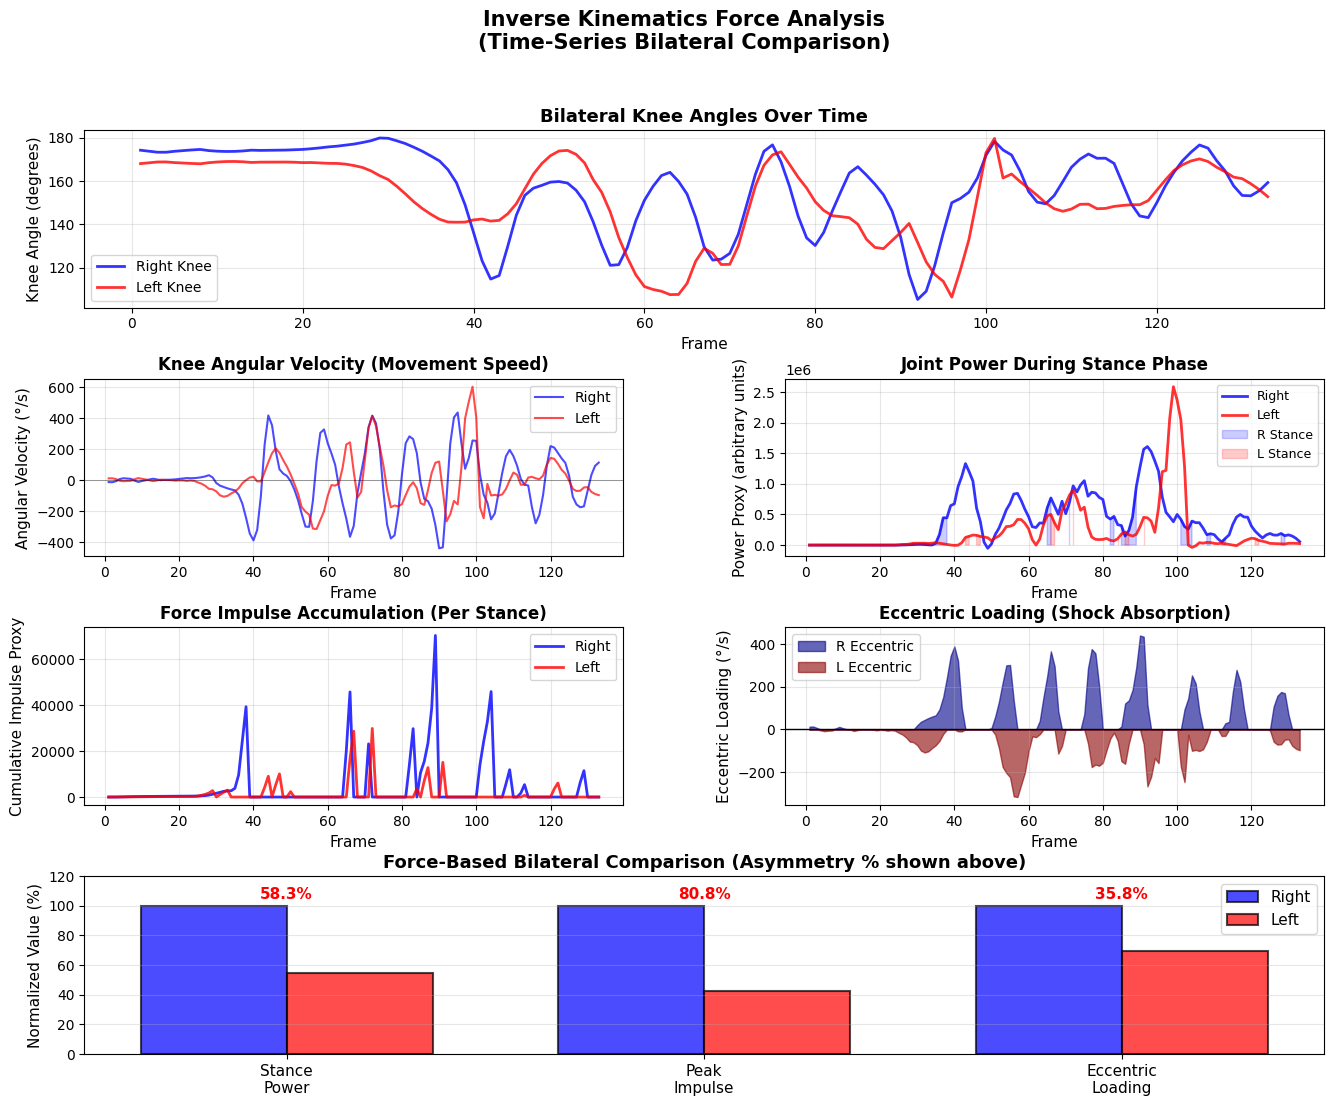

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ==============================================================
# Load CSV
# ==============================================================
CSV_FILE = "2026_05_13_example.csv"
df = pd.read_csv(CSV_FILE)

print("="*70)
print("ADVANCED INVERSE KINEMATICS & FORCE ANALYSIS")
print("="*70)
print(f"Loaded {len(df)} frames\n")

fps = 30.0
dt = 1.0 / fps

# ==============================================================
# 1. Calculate Joint Angles (Inverse Kinematics)
# ==============================================================

def calculate_angle(p1, p2, p3):
    v1 = p1 - p2
    v2 = p3 - p2
    cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-6)
    cos_angle = np.clip(cos_angle, -1.0, 1.0)
    return np.degrees(np.arccos(cos_angle))

right_knee_angles = []
left_knee_angles = []
right_hip_angles = []
left_hip_angles = []

for idx, row in df.iterrows():
    r_hip = np.array([row['right_hip_x_smooth'], row['right_hip_y_smooth']])
    r_knee = np.array([row['right_knee_x_smooth'], row['right_knee_y_smooth']])
    r_ankle = np.array([row['right_ankle_x_smooth'], row['right_ankle_y_smooth']])
    
    l_hip = np.array([row['left_hip_x_smooth'], row['left_hip_y_smooth']])
    l_knee = np.array([row['left_knee_x_smooth'], row['left_knee_y_smooth']])
    l_ankle = np.array([row['left_ankle_x_smooth'], row['left_ankle_y_smooth']])
    
    pelvis = np.array([row['pelvis_x_smooth'], row['pelvis_y_smooth']])
    
    right_knee_angles.append(calculate_angle(r_hip, r_knee, r_ankle))
    left_knee_angles.append(calculate_angle(l_hip, l_knee, l_ankle))
    right_hip_angles.append(calculate_angle(pelvis, r_hip, r_knee))
    left_hip_angles.append(calculate_angle(pelvis, l_hip, l_knee))

df['right_knee_angle'] = right_knee_angles
df['left_knee_angle'] = left_knee_angles
df['right_hip_angle'] = right_hip_angles
df['left_hip_angle'] = left_hip_angles

# ==============================================================
# 2. Angular Velocity & Acceleration
# ==============================================================

for joint in ['right_knee', 'left_knee', 'right_hip', 'left_hip']:
    df[f'{joint}_angular_velocity'] = np.gradient(df[f'{joint}_angle'], dt)
    df[f'{joint}_angular_acceleration'] = np.gradient(df[f'{joint}_angular_velocity'], dt)

# ==============================================================
# 3. JOINT POWER Estimation (Simplified)
# ==============================================================
# Power ≈ Torque × Angular Velocity
# For simplified analysis: Power_proxy = |angular_velocity| × |angular_acceleration|

df['right_knee_power_proxy'] = np.abs(df['right_knee_angular_velocity']) * np.abs(df['right_knee_angular_acceleration'])
df['left_knee_power_proxy'] = np.abs(df['left_knee_angular_velocity']) * np.abs(df['left_knee_angular_acceleration'])

# Smooth power to remove spikes
from scipy.signal import savgol_filter
window = 7
df['right_knee_power_smooth'] = savgol_filter(df['right_knee_power_proxy'], window, 2)
df['left_knee_power_smooth'] = savgol_filter(df['left_knee_power_proxy'], window, 2)

# ==============================================================
# 4. IMPULSE Estimation (Force × Time)
# ==============================================================
# During stance phase, integrate power to get work/impulse proxy

right_stance_mask = df['right_foot_state'] == 'contact'
left_stance_mask = df['left_foot_state'] == 'contact'

df['right_impulse_proxy'] = 0.0
df['left_impulse_proxy'] = 0.0

# Cumulative during each stance
right_impulse = 0
left_impulse = 0

for idx in range(len(df)):
    if right_stance_mask.iloc[idx]:
        right_impulse += df.loc[idx, 'right_knee_power_smooth'] * dt
    else:
        right_impulse = 0
    
    if left_stance_mask.iloc[idx]:
        left_impulse += df.loc[idx, 'left_knee_power_smooth'] * dt
    else:
        left_impulse = 0
    
    df.at[idx, 'right_impulse_proxy'] = right_impulse
    df.at[idx, 'left_impulse_proxy'] = left_impulse

# ==============================================================
# 5. ECCENTRIC vs CONCENTRIC Loading
# ==============================================================
# Negative angular velocity = flexion (eccentric/absorbing)
# Positive angular velocity = extension (concentric/generating)

df['right_knee_eccentric'] = df['right_knee_angular_velocity'].apply(lambda x: abs(x) if x < 0 else 0)
df['left_knee_eccentric'] = df['left_knee_angular_velocity'].apply(lambda x: abs(x) if x < 0 else 0)

df['right_knee_concentric'] = df['right_knee_angular_velocity'].apply(lambda x: x if x > 0 else 0)
df['left_knee_concentric'] = df['left_knee_angular_velocity'].apply(lambda x: x if x > 0 else 0)

# ==============================================================
# 6. Calculate Summary Statistics
# ==============================================================

print("Calculating biomechanical force metrics...\n")

# Average power during stance
right_stance_power = df[right_stance_mask]['right_knee_power_smooth'].mean()
left_stance_power = df[left_stance_mask]['left_knee_power_smooth'].mean()
power_asym = abs(right_stance_power - left_stance_power) / ((right_stance_power + left_stance_power) / 2) * 100

# Peak impulse
right_peak_impulse = df['right_impulse_proxy'].max()
left_peak_impulse = df['left_impulse_proxy'].max()
impulse_asym = abs(right_peak_impulse - left_peak_impulse) / ((right_peak_impulse + left_peak_impulse) / 2) * 100

# Eccentric loading (shock absorption)
right_eccentric_total = df['right_knee_eccentric'].sum()
left_eccentric_total = df['left_knee_eccentric'].sum()
eccentric_asym = abs(right_eccentric_total - left_eccentric_total) / ((right_eccentric_total + left_eccentric_total) / 2) * 100

print("="*70)
print("FORCE-BASED BILATERAL ASSESSMENT")
print("="*70)
print(f"\n{'Metric':<30} {'Right':<15} {'Left':<15} {'Asymmetry'}")
print("-"*70)
print(f"{'Avg Stance Power (proxy)':<30} {right_stance_power:<15.1f} {left_stance_power:<15.1f} {power_asym:.1f}%")
print(f"{'Peak Impulse (proxy)':<30} {right_peak_impulse:<15.1f} {left_peak_impulse:<15.1f} {impulse_asym:.1f}%")
print(f"{'Eccentric Loading (total)':<30} {right_eccentric_total:<15.1f} {left_eccentric_total:<15.1f} {eccentric_asym:.1f}%")
print("="*70)

# ==============================================================
# 7. TIME-SERIES VISUALIZATION (Line Charts)
# ==============================================================

fig = plt.figure(figsize=(16, 12))
gs = GridSpec(4, 2, figure=fig, hspace=0.4, wspace=0.3)

# Graph 1: Joint Angles Over Time
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(df['frame'], df['right_knee_angle'], 'b-', linewidth=2, label='Right Knee', alpha=0.8)
ax1.plot(df['frame'], df['left_knee_angle'], 'r-', linewidth=2, label='Left Knee', alpha=0.8)
ax1.set_ylabel('Knee Angle (degrees)', fontsize=11)
ax1.set_title('Bilateral Knee Angles Over Time', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlabel('Frame', fontsize=11)

# Graph 2: Angular Velocity (Rate of Movement)
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(df['frame'], df['right_knee_angular_velocity'], 'b-', linewidth=1.5, label='Right', alpha=0.7)
ax2.plot(df['frame'], df['left_knee_angular_velocity'], 'r-', linewidth=1.5, label='Left', alpha=0.7)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)
ax2.set_ylabel('Angular Velocity (°/s)', fontsize=11)
ax2.set_xlabel('Frame', fontsize=11)
ax2.set_title('Knee Angular Velocity (Movement Speed)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# Graph 3: Power Proxy Over Time
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(df['frame'], df['right_knee_power_smooth'], 'b-', linewidth=2, label='Right', alpha=0.8)
ax3.plot(df['frame'], df['left_knee_power_smooth'], 'r-', linewidth=2, label='Left', alpha=0.8)
ax3.fill_between(df['frame'], 0, df['right_knee_power_smooth'], where=right_stance_mask, 
                 alpha=0.2, color='blue', label='R Stance')
ax3.fill_between(df['frame'], 0, df['left_knee_power_smooth'], where=left_stance_mask, 
                 alpha=0.2, color='red', label='L Stance')
ax3.set_ylabel('Power Proxy (arbitrary units)', fontsize=11)
ax3.set_xlabel('Frame', fontsize=11)
ax3.set_title('Joint Power During Stance Phase', fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# Graph 4: Impulse Accumulation
ax4 = fig.add_subplot(gs[2, 0])
ax4.plot(df['frame'], df['right_impulse_proxy'], 'b-', linewidth=2, label='Right', alpha=0.8)
ax4.plot(df['frame'], df['left_impulse_proxy'], 'r-', linewidth=2, label='Left', alpha=0.8)
ax4.set_ylabel('Cumulative Impulse Proxy', fontsize=11)
ax4.set_xlabel('Frame', fontsize=11)
ax4.set_title('Force Impulse Accumulation (Per Stance)', fontsize=12, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)

# Graph 5: Eccentric vs Concentric
ax5 = fig.add_subplot(gs[2, 1])
ax5.fill_between(df['frame'], 0, df['right_knee_eccentric'], alpha=0.6, color='darkblue', label='R Eccentric')
ax5.fill_between(df['frame'], 0, -df['left_knee_eccentric'], alpha=0.6, color='darkred', label='L Eccentric')
ax5.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax5.set_ylabel('Eccentric Loading (°/s)', fontsize=11)
ax5.set_xlabel('Frame', fontsize=11)
ax5.set_title('Eccentric Loading (Shock Absorption)', fontsize=12, fontweight='bold')
ax5.legend(fontsize=10)
ax5.grid(True, alpha=0.3)

# Graph 6: Summary Bar Chart - All Force Metrics
ax6 = fig.add_subplot(gs[3, :])
metric_names = ['Stance\nPower', 'Peak\nImpulse', 'Eccentric\nLoading']
asymmetries = [power_asym, impulse_asym, eccentric_asym]
right_vals = [right_stance_power, right_peak_impulse, right_eccentric_total]
left_vals = [left_stance_power, left_peak_impulse, left_eccentric_total]

# Normalize for comparison
max_vals = [max(r, l) for r, l in zip(right_vals, left_vals)]
right_norm = [r/m*100 for r, m in zip(right_vals, max_vals)]
left_norm = [l/m*100 for l, m in zip(left_vals, max_vals)]

x = np.arange(len(metric_names))
width = 0.35

bars1 = ax6.bar(x - width/2, right_norm, width, label='Right', color='blue', alpha=0.7, edgecolor='black', linewidth=1.5)
bars2 = ax6.bar(x + width/2, left_norm, width, label='Left', color='red', alpha=0.7, edgecolor='black', linewidth=1.5)

# Add asymmetry labels
for i, asym in enumerate(asymmetries):
    color = 'red' if asym > 15 else 'green'
    ax6.text(i, 105, f'{asym:.1f}%', ha='center', fontsize=11, fontweight='bold', color=color)

ax6.set_ylabel('Normalized Value (%)', fontsize=11)
ax6.set_title('Force-Based Bilateral Comparison (Asymmetry % shown above)', fontsize=13, fontweight='bold')
ax6.set_xticks(x)
ax6.set_xticklabels(metric_names, fontsize=11)
ax6.legend(fontsize=11)
ax6.set_ylim([0, 120])
ax6.grid(True, alpha=0.3, axis='y')

plt.suptitle('Inverse Kinematics Force Analysis\n(Time-Series Bilateral Comparison)', 
             fontsize=15, fontweight='bold')

plt.savefig('inverse_kinematics_force_analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Advanced force analysis graph saved\n")

# ==============================================================
# 8. COMPREHENSIVE FORCE-BASED REPORT
# ==============================================================

print("="*70)
print("FORCE-BASED BILATERAL ASSESSMENT")
print("="*70)

force_metrics = {
    'Metric': [
        'Stance Phase Power',
        'Peak Impulse',
        'Eccentric Loading (Shock Absorption)',
        'Concentric Loading (Force Generation)'
    ],
    'Right': [
        f"{right_stance_power:.1f}",
        f"{right_peak_impulse:.1f}",
        f"{right_eccentric_total:.1f}",
        f"{df['right_knee_concentric'].sum():.1f}"
    ],
    'Left': [
        f"{left_stance_power:.1f}",
        f"{left_peak_impulse:.1f}",
        f"{left_eccentric_total:.1f}",
        f"{df['left_knee_concentric'].sum():.1f}"
    ],
    'Asymmetry_%': [
        power_asym,
        impulse_asym,
        eccentric_asym,
        abs(df['right_knee_concentric'].sum() - df['left_knee_concentric'].sum()) / 
        ((df['right_knee_concentric'].sum() + df['left_knee_concentric'].sum()) / 2) * 100
    ]
}

force_df = pd.DataFrame(force_metrics)
force_df['Risk'] = force_df['Asymmetry_%'].apply(lambda x: '⚠️ HIGH' if x > 15 else '✓ Normal')

print("\n" + force_df.to_string(index=False))
print("\n" + "="*70)

# Clinical flags
high_risk_count = (force_df['Asymmetry_%'] > 15).sum()

print(f"\nHIGH ASYMMETRY FLAGS: {high_risk_count}/4 force metrics")

if high_risk_count >= 3:
    print("\n⚠️  SEVERE BILATERAL IMBALANCE")
    print("   Multiple force production asymmetries detected")
    print("   Dominant leg compensating for weaker side")
elif high_risk_count >= 2:
    print("\n⚠️  MODERATE BILATERAL IMBALANCE")
    print("   Significant force asymmetries detected")
elif high_risk_count == 1:
    print("\n⚡ MINOR ASYMMETRY")
    print("   Single force metric elevated")
else:
    print("\n✓ BILATERAL SYMMETRY NORMAL")
    print("   Force production balanced between legs")

print("="*70)

# ==============================================================
# 9. INJURY MECHANISM INSIGHTS
# ==============================================================

print("\nBIOMECHANICAL INSIGHTS:")
print("-"*70)

# Which leg absorbs more force?
if right_eccentric_total > left_eccentric_total * 1.15:
    print("• Right leg absorbing MORE shock (eccentric loading)")
    print("  → Higher ACL injury risk on right side")
    print("  → May indicate left leg weakness forcing right compensation")
elif left_eccentric_total > right_eccentric_total * 1.15:
    print("• Left leg absorbing MORE shock (eccentric loading)")
    print("  → Higher ACL injury risk on left side")
    print("  → May indicate right leg weakness forcing left compensation")
else:
    print("• Eccentric loading balanced (good shock absorption symmetry)")

# Power output comparison
if right_stance_power > left_stance_power * 1.15:
    print("\n• Right leg generating MORE power during stance")
    print("  → Left leg may be weak or inhibited")
elif left_stance_power > right_stance_power * 1.15:
    print("\n• Left leg generating MORE power during stance")
    print("  → Right leg may be weak or inhibited")
else:
    print("\n• Power generation balanced")

# Impulse (total force application)
if right_peak_impulse > left_peak_impulse * 1.15:
    print("\n• Right leg applying MORE total force")
    print("  → Overuse risk on right side")
elif left_peak_impulse > right_peak_impulse * 1.15:
    print("\n• Left leg applying MORE total force")
    print("  → Overuse risk on left side")
else:
    print("\n• Force application balanced")

print("="*70)

# Export
force_df.to_csv('force_based_injury_report.csv', index=False)
print("\n✓ Force analysis report saved: force_based_injury_report.csv")

print("\n" + "="*70)
print("INTERPRETATION GUIDE")
print("="*70)
print("\nThe time-series graphs show:")
print("• Top: Actual joint angles changing during movement")
print("• Middle-left: How fast joints are moving (velocity)")
print("• Middle-right: Power output (effort level)")
print("• Bottom-left: Cumulative force during each stance phase")
print("• Bottom-right: Shock absorption (eccentric) loading")
print("• Bottom: Summary showing which leg works harder overall")
print("\nCLEARER than ROM/Work because:")
print("  ✓ Shows exact timing of force application")
print("  ✓ Separates shock absorption vs force generation")
print("  ✓ Visualizes stance-by-stance differences")
print("  ✓ Impulse shows total force, not just movement speed")
print("="*70)

In [33]:
import cv2
import numpy as np

# Paths
VIDEO_PATH = r"C:\Users\lynch\OneDrive\Syracuse\Computer Vision\Women's Lacrosse\YOLO Model\IMG_4572.MOV"
OUTPUT_VIDEO = "2026_05_13_Example_output.avi"

# Read first frame from originalb

cap_orig = cv2.VideoCapture(VIDEO_PATH)
ret, frame_orig = cap_orig.read()
cap_orig.release()

# Rotate to match output
frame_orig = cv2.rotate(frame_orig, cv2.ROTATE_90_CLOCKWISE)

# Read first frame from output
cap_out = cv2.VideoCapture(OUTPUT_VIDEO)
ret2, frame_out = cap_out.read()
cap_out.release()

# Create side-by-side
side_by_side = np.hstack([frame_orig, frame_out])

# Save
cv2.imwrite('first_frame_comparison.jpg', side_by_side, [cv2.IMWRITE_JPEG_QUALITY, 95])
print("✓ Saved: first_frame_comparison.jpg")

✓ Saved: first_frame_comparison.jpg


In [2]:
import cv2
import numpy as np
import pandas as pd

# Load your CSV and original video
CSV_FILE = "2026_05_13_example.csv"
VIDEO_PATH = r"C:\Users\lynch\OneDrive\Syracuse\Computer Vision\Women's Lacrosse\YOLO Model\IMG_4572.MOV"

df = pd.read_csv(CSV_FILE)

# Get first frame from video
cap = cv2.VideoCapture(VIDEO_PATH)
ret, frame = cap.read()
cap.release()

# Rotate to match processing
frame = cv2.rotate(frame, cv2.ROTATE_90_CLOCKWISE)

# Frame index (first frame)
frame_idx = 0

# Skeleton structure
SKELETON_EDGES = [
    (10, 8), (10, 9), (8, 6), (9, 7), (6, 2), (7, 5),
    (2, 1), (5, 4), (1, 0), (4, 3),
    (10, 11), (11, 12), (12, 13), (13, 14),
    (10, 15), (15, 16), (16, 17), (17, 18),
    (10, 19)
]

JOINT_NAMES = [
    'right_toe', 'right_heel', 'right_ankle',
    'left_toe', 'left_heel', 'left_ankle',
    'right_knee', 'left_knee',
    'right_hip', 'left_hip', 'pelvis',
    'right_shoulder', 'right_elbow', 'right_wrist', 'right_hand',
    'left_shoulder', 'left_elbow', 'left_wrist', 'left_hand',
    'head'
]

FOOT_JOINTS = {0, 1, 2, 3, 4, 5}
LEG_JOINTS = {0, 1, 2, 3, 4, 5, 6, 7, 8, 9}

# Get keypoints for first frame
keypoints = []
confs = []
for joint in JOINT_NAMES:
    x = df.loc[frame_idx, f'{joint}_x_smooth']
    y = df.loc[frame_idx, f'{joint}_y_smooth']
    c = df.loc[frame_idx, f'{joint}_conf']
    keypoints.append([x, y])
    confs.append(c)

keypoints = np.array(keypoints)
confs = np.array(confs)

# Draw skeleton on frame
annotated = frame.copy()

# Draw skeleton lines
for (p, c) in SKELETON_EDGES:
    if confs[p] > 0.25 and confs[c] > 0.25:
        pt1 = (int(keypoints[p][0]), int(keypoints[p][1]))
        pt2 = (int(keypoints[c][0]), int(keypoints[c][1]))
        
        if {p, c} & LEG_JOINTS:
            thickness = 4
            color = (0, 255, 0) if {p, c} & FOOT_JOINTS else (0, 255, 255)
        elif {p, c} & {19}:
            thickness = 2
            color = (0, 0, 255)
        else:
            thickness = 2
            color = (255, 140, 0)
        
        cv2.line(annotated, pt1, pt2, color, thickness)

# Draw keypoints
for i, ((x, y), conf) in enumerate(zip(keypoints, confs)):
    if conf > 0.25:
        if i in LEG_JOINTS:
            radius = 6
            color = (0, 255, 0) if i in FOOT_JOINTS else (0, 255, 255)
        elif i == 10:
            radius = 7
            color = (255, 0, 255)
        else:
            radius = 4
            color = (0, 255, 255)
        
        cv2.circle(annotated, (int(x), int(y)), radius, color, -1)
        cv2.circle(annotated, (int(x), int(y)), radius+1, (0, 0, 0), 1)

# Save
cv2.imwrite('first_frame_with_skeleton.jpg', annotated, [cv2.IMWRITE_JPEG_QUALITY, 95])
print("✓ Saved: first_frame_with_skeleton.jpg")

✓ Saved: first_frame_with_skeleton.jpg
